In [1]:
!pip install -q transformers torch torchvision pandas scikit-learn pillow matplotlib tqdm

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from transformers import CLIPProcessor, CLIPModel
from sklearn.neighbors import NearestNeighbors

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -q "/content/drive/MyDrive/archive.zip" -d "/content/"

In [5]:
import os

dataset_path = "/content"

styles_path = os.path.join(dataset_path, "styles.csv")
images_path = os.path.join(dataset_path, "images")

In [6]:
print(os.path.exists(styles_path))
print(os.path.exists(images_path))

True
True


In [7]:
import pandas as pd

styles = pd.read_csv(
    styles_path,
    on_bad_lines="skip"
)

print(styles.shape)

styles.head()

(44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [8]:
tshirts = styles[
    (styles["gender"] == "Men") &
    (styles["articleType"] == "Tshirts")
].copy()

print("Men T-Shirts :", len(tshirts))

Men T-Shirts : 5243


In [9]:
tshirts["image_path"] = tshirts["id"].astype(str) + ".jpg"

tshirts["image_path"] = tshirts["image_path"].apply(
    lambda x: os.path.join(images_path, x)
)

In [10]:
tshirts["exists"] = tshirts["image_path"].apply(os.path.exists)

print(tshirts["exists"].value_counts())

exists
True     5242
False       1
Name: count, dtype: int64


In [11]:
tshirts = tshirts[
    tshirts["exists"]
].reset_index(drop=True)

print("Final Images :", len(tshirts))

Final Images : 5242


In [12]:
historical_df = tshirts.sample(
    n=3145,
    random_state=42
).reset_index(drop=True)

print("Historical Images :", len(historical_df))

Historical Images : 3145


In [13]:
new_market_df = tshirts[
    ~tshirts["id"].isin(historical_df["id"])
].reset_index(drop=True)

print("New Market Images :", len(new_market_df))

New Market Images : 2097


In [14]:
required_preferred = 1468
required_not_preferred = 1677

preferred_colours = [
    "Black",
    "Grey",
    "Navy Blue",
    "White",
    "Blue"
]

preferred_pool = historical_df[
    historical_df["baseColour"].isin(preferred_colours)
].copy()

not_preferred_pool = historical_df[
    ~historical_df["baseColour"].isin(preferred_colours)
].copy()

preferred_final = preferred_pool.sample(
    n=required_preferred,
    random_state=42
)

remaining_needed = required_not_preferred - len(not_preferred_pool)

extra_not_preferred = preferred_pool.drop(
    preferred_final.index
).sample(
    n=remaining_needed,
    random_state=42
)

not_preferred_final = pd.concat(
    [not_preferred_pool, extra_not_preferred],
    ignore_index=True
)

preferred_final["label"] = 1
not_preferred_final["label"] = 0

preference_df = pd.concat(
    [preferred_final, not_preferred_final],
    ignore_index=True
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(preference_df["label"].value_counts())

label
0    1677
1    1468
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    preference_df,
    test_size=898,
    random_state=42,
    stratify=preference_df["label"]
)

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
0    1198
1    1049
Name: count, dtype: int64
label
0    479
1    419
Name: count, dtype: int64


In [16]:
from transformers import CLIPModel, CLIPProcessor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model.eval()

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [17]:
from PIL import Image
import numpy as np
from tqdm import tqdm

def make_embeddings_batch(dataframe, batch_size=32):

    embeddings = []

    with torch.no_grad():

        for start in tqdm(range(0, len(dataframe), batch_size)):

            batch = dataframe.iloc[start:start+batch_size]

            batch_images = [
                Image.open(path).convert("RGB")
                for path in batch["image_path"]
            ]

            inputs = clip_processor(
                images=batch_images,
                return_tensors="pt",
                padding=True
            ).to(device)

            outputs = clip_model.vision_model(
                pixel_values=inputs["pixel_values"]
            )

            pooled = outputs.pooler_output

            emb = clip_model.visual_projection(pooled)

            emb = emb / emb.norm(dim=-1, keepdim=True)

            embeddings.append(emb.cpu().numpy())

    return np.vstack(embeddings)

In [18]:
train_embeddings = make_embeddings_batch(train_df)

test_embeddings = make_embeddings_batch(test_df)

new_market_embeddings = make_embeddings_batch(new_market_df)

print(train_embeddings.shape)
print(test_embeddings.shape)
print(new_market_embeddings.shape)

100%|██████████| 66/66 [00:07<00:00,  8.33it/s]

(2247, 512)
(898, 512)
(2097, 512)


In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="cosine"
)

knn_model.fit(
    train_embeddings,
    train_df["label"]
)

print("KNN Training Completed!")

KNN Training Completed!


In [20]:
predictions = knn_model.predict(test_embeddings)

probabilities = knn_model.predict_proba(test_embeddings)[:,1]

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy :", accuracy_score(
    test_df["label"],
    predictions
))

print("\nClassification Report\n")

print(classification_report(
    test_df["label"],
    predictions
))

print("\nConfusion Matrix\n")

print(confusion_matrix(
    test_df["label"],
    predictions
))

Accuracy : 0.6525612472160356

Classification Report

              precision    recall  f1-score   support

           0       0.68      0.65      0.67       479
           1       0.62      0.65      0.64       419

    accuracy                           0.65       898
   macro avg       0.65      0.65      0.65       898
weighted avg       0.65      0.65      0.65       898


Confusion Matrix

[[312 167]
 [145 274]]


In [22]:
new_market_df["preference_score"] = knn_model.predict_proba(
    new_market_embeddings
)[:,1]

top2 = new_market_df.sort_values(
    by="preference_score",
    ascending=False
).head(2)

top2[
    [
        "id",
        "baseColour",
        "preference_score"
    ]
]

,id,baseColour,preference_score
243,32640,White,1.0
1704,32462,White,1.0


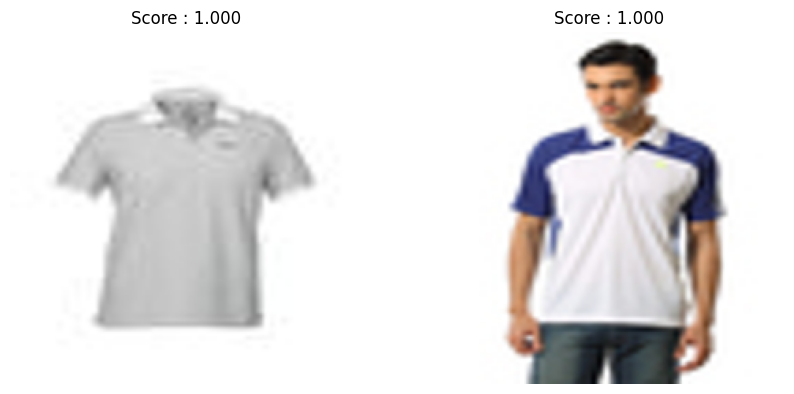

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1,2,figsize=(10,5))

for ax, (_, row) in zip(axes, top2.iterrows()):

    image = Image.open(row["image_path"]).convert("RGB")
    image = image.resize((224,224))

    ax.imshow(image)

    ax.set_title(
        f"Score : {row['preference_score']:.3f}"
    )

    ax.axis("off")

plt.show()

In [24]:
from transformers import AutoProcessor, LlavaForConditionalGeneration
from PIL import Image
import torch
import gc

# -----------------------------
# Device
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Load LLaVA
# -----------------------------
model_name = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(model_name)

model = LlavaForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("LLaVA Loaded Successfully!")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/70.1k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

LLaVA Loaded Successfully!


In [27]:
for rank, (_, row) in enumerate(top2.iterrows(), start=1):

    image = Image.open(row["image_path"]).convert("RGB")

    prompt = """
This T-shirt has already been recommended by a KNN model based on CLIP image embeddings.

Explain in 3 short sentences:
1. Why this T-shirt may match the user's preference.
2. Mention its color, style, or design.
3. Keep the explanation simple.
"""

    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text_prompt = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True
    )

    inputs = processor(
        images=image,
        text=text_prompt,
        return_tensors="pt"
    ).to(device, torch.float16)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False
        )

    response = processor.decode(
        output[0],
        skip_special_tokens=True
    ).strip()

    print("=" * 70)
    print(f"Recommendation {rank}")
    print(f"Image ID: {row['id']}")
    print(f"Color: {row['baseColour']}")
    print(f"Preference Score: {row['preference_score']:.4f}")
    print("\nLLaVA Explanation:")
    print(response)

    del inputs
    del output
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Recommendation 1
Image ID: 32640
Color: White
Preference Score: 1.0000

LLaVA Explanation:
USER:  

This T-shirt has already been recommended by a KNN model based on CLIP image embeddings.

Explain in 3 short sentences:
1. Why this T-shirt may match the user's preference.
2. Mention its color, style, or design.
3. Keep the explanation simple.
 ASSISTANT: This T-shirt is grey and has a collar, making it a comfortable and stylish choice for the user.
Recommendation 2
Image ID: 32462
Color: White
Preference Score: 1.0000

LLaVA Explanation:
USER:  

This T-shirt has already been recommended by a KNN model based on CLIP image embeddings.

Explain in 3 short sentences:
1. Why this T-shirt may match the user's preference.
2. Mention its color, style, or design.
3. Keep the explanation simple.
 ASSISTANT: The T-shirt is blue and white, and it has a design that may match the user's preference.
